In [1426]:
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from scipy.optimize import minimize
from imblearn.over_sampling import SMOTE

from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [1427]:
df = pd.read_csv('diabetes.csv')


In [1428]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [1429]:
df.shape

(768, 9)

In [1430]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [1431]:
print(df.columns)


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [1432]:
df.isnull().values.any()


False

In [1433]:
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [1434]:
df["Outcome"].unique()

array([1, 0], dtype=int64)

In [1435]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [1436]:
correlation_matrix = df.corr()
print(correlation_matrix)


                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

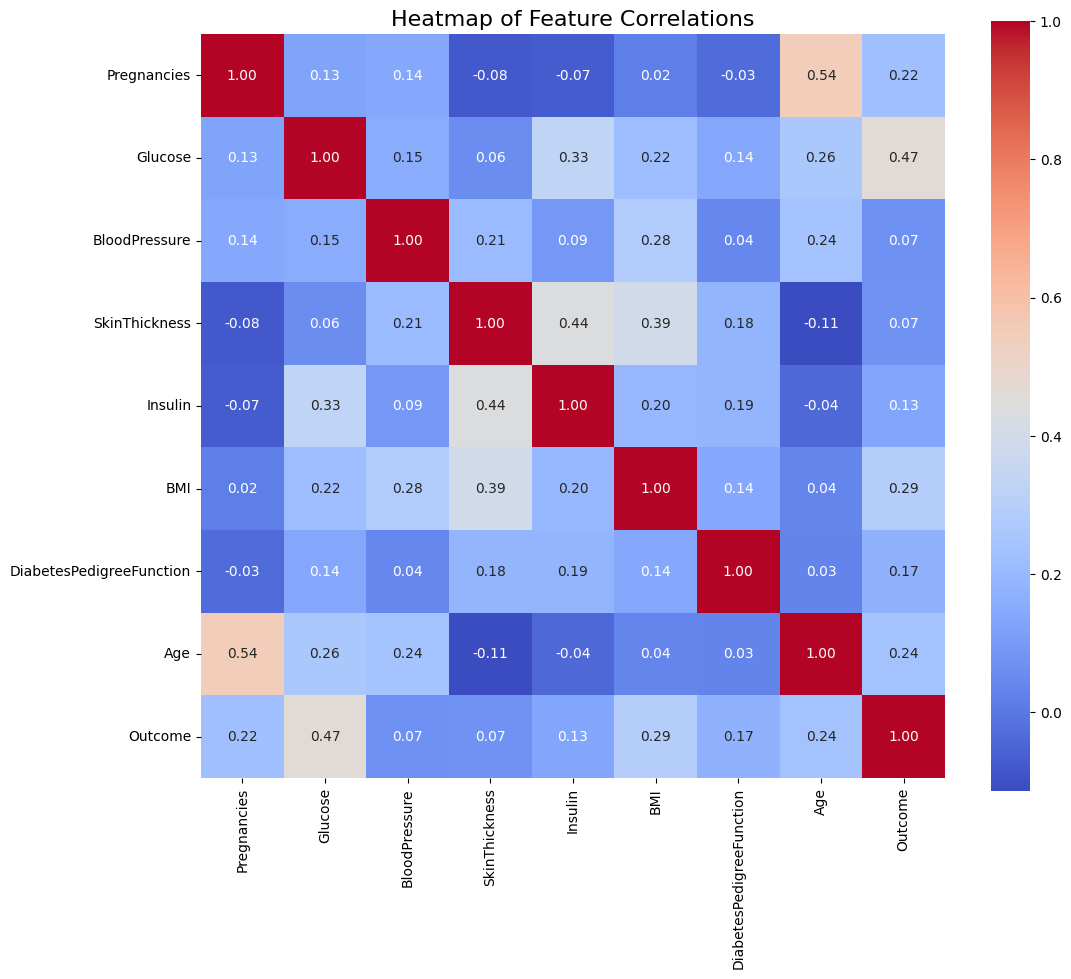

In [1437]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap of Feature Correlations", fontsize=16)
plt.show()

In [1438]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

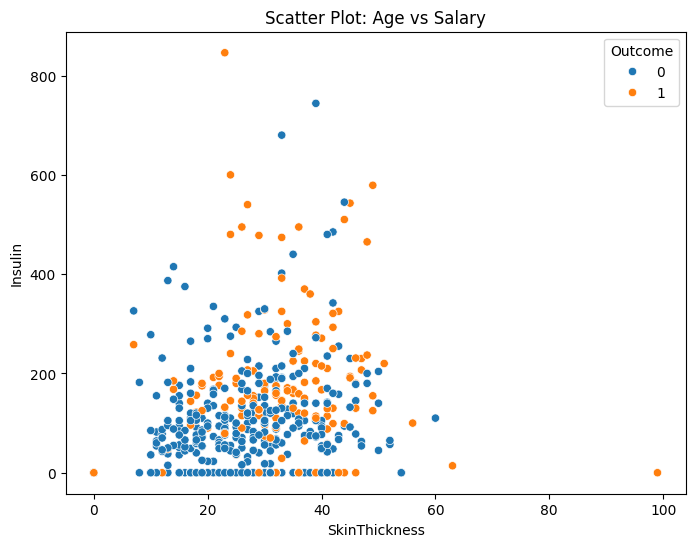

In [1439]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='SkinThickness', y='Insulin', hue='Outcome')
plt.title('Scatter Plot: Age vs Salary')
plt.show()

In [1440]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

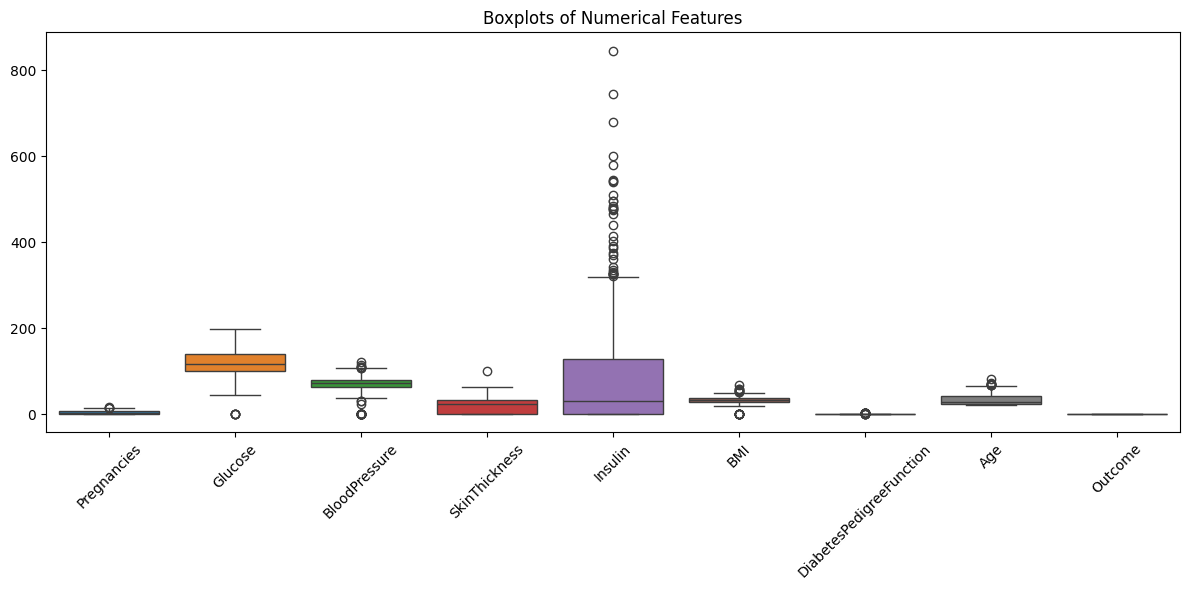

In [1441]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Features')
plt.tight_layout()
plt.show()

In [1442]:
df = pd.read_csv('diabetes.csv')


In [1443]:
(0 in df["SkinThickness"].values)  
print((df["SkinThickness"] == 0).sum())

227


In [1444]:
median_value = df["SkinThickness"][df["SkinThickness"] != 0].median()
df["SkinThickness"] = df["SkinThickness"].replace(0, median_value)


In [1445]:
(0 in df["Glucose"].values)  
print((df["Glucose"] == 0).sum())

5


In [1446]:
median_value = df["Glucose"][df["Glucose"] != 0].median()
df["Glucose"] = df["Glucose"].replace(0, median_value)


In [1447]:
(0 in df["BloodPressure"].values)  
print((df["BloodPressure"] == 0).sum())

35


In [1448]:
median_value = df["BloodPressure"][df["BloodPressure"] != 0].median()
df["BloodPressure"] = df["BloodPressure"].replace(0, median_value)


In [1449]:
(0 in df["Insulin"].values)  
print((df["Insulin"] == 0).sum())

374


In [1450]:
median_value = df["Insulin"][df["Insulin"] != 0].median()
df["Insulin"] = df["Insulin"].replace(0, median_value)


In [1451]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [1452]:


Q1 = df['Glucose'].quantile(0.25)
Q3 = df['Glucose'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

median = df['Glucose'].median()

df['Glucose'] = df['Glucose'].apply(
    lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)
)


In [1453]:


Q1 = df["SkinThickness"].quantile(0.25)
Q3 = df["SkinThickness"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

median = df["SkinThickness"].median()

df["SkinThickness"] = df["SkinThickness"].apply(
    lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)
)


In [1454]:


Q1 = df["Insulin"].quantile(0.25)
Q3 = df["Insulin"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

median = df["Insulin"].median()

df["Insulin"] = df["Insulin"].apply(
    lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)
)


In [1455]:


Q1 = df["BloodPressure"].quantile(0.25)
Q3 = df["BloodPressure"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

median = df["BloodPressure"].median()

df["BloodPressure"] = df["BloodPressure"].apply(
    lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)
)

In [1456]:


Q1 = df["BMI"].quantile(0.25)
Q3 = df["BMI"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

median = df["BMI"].median()

df["BMI"] = df["BMI"].apply(
    lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)
)

In [1457]:


Q1 = df["Pregnancies"].quantile(0.25)
Q3 = df["Pregnancies"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

median = df["Pregnancies"].median()


df["Pregnancies"] = df["Pregnancies"].apply(
    lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)

)

In [1458]:


Q1 = df["DiabetesPedigreeFunction"].quantile(0.25)
Q3 = df["DiabetesPedigreeFunction"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

median = df["DiabetesPedigreeFunction"].median()


df["DiabetesPedigreeFunction"] = df["DiabetesPedigreeFunction"].apply(
    lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)

)

In [1459]:


Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

median = df["Age"].median()


df["Age"] = df["Age"].apply(
    lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)

)

In [1460]:
df.iloc[:, :-1]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148,72.0,35.0,125.000,33.6,0.627,50.0
1,1.0,85,66.0,29.0,125.000,26.6,0.351,31.0
2,8.0,183,64.0,29.0,125.000,23.3,0.672,32.0
3,1.0,89,66.0,23.0,112.875,28.1,0.167,21.0
4,0.0,137,40.0,35.0,135.875,43.1,1.200,33.0
...,...,...,...,...,...,...,...,...
763,10.0,101,76.0,42.5,135.875,32.9,0.171,63.0
764,2.0,122,70.0,27.0,125.000,36.8,0.340,27.0
765,5.0,121,72.0,23.0,112.875,26.2,0.245,30.0
766,1.0,126,60.0,29.0,125.000,30.1,0.349,47.0


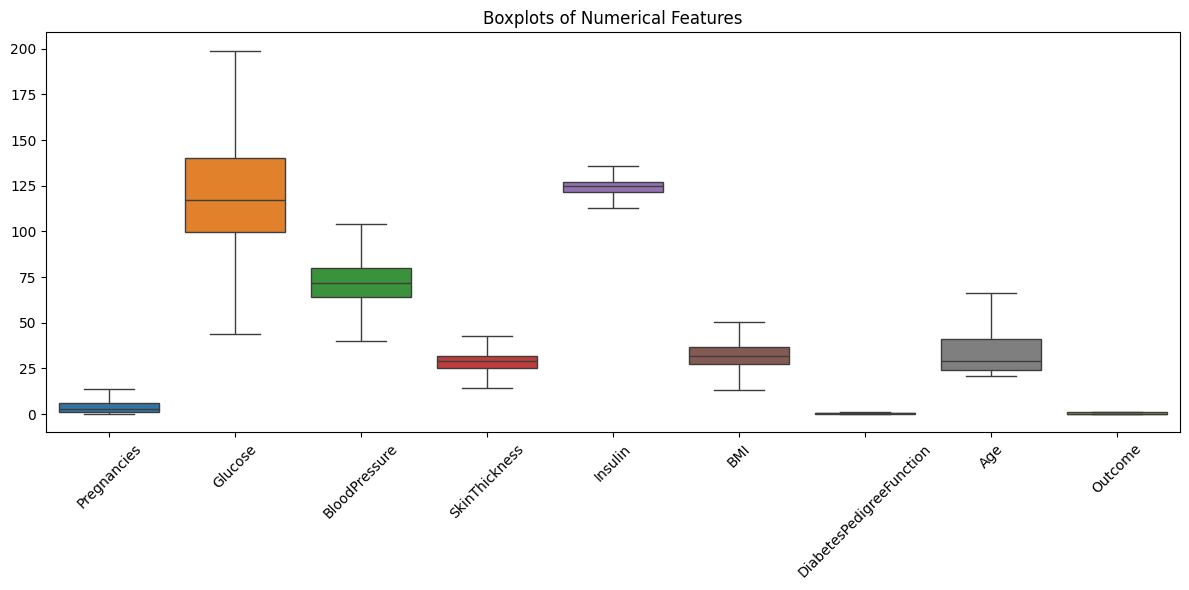

In [1461]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Features')
plt.tight_layout()
plt.show()

In [1462]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [1463]:
correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [1464]:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df.iloc[:,-1]

In [1465]:
0 in df["Glucose"].value_counts()

False

In [1466]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

In [1467]:
X_train.shape

(691, 8)

In [1468]:

k_range = range(1, 21)
cv_scores = []

for k in k_range:
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('smote', SMOTE(sampling_strategy=0.8)),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores.append(np.mean(scores))

best_k = k_range[np.argmax(cv_scores)]
print(f"✅ Best k from cross-validation: {best_k}")

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Final Accuracy on Test: {acc:.4f}\n")

print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("🧱 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


✅ Best k from cross-validation: 18

🎯 Final Accuracy on Test: 0.7403

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.72      0.78        50
           1       0.60      0.78      0.68        27

    accuracy                           0.74        77
   macro avg       0.73      0.75      0.73        77
weighted avg       0.77      0.74      0.75        77

🧱 Confusion Matrix:
[[36 14]
 [ 6 21]]


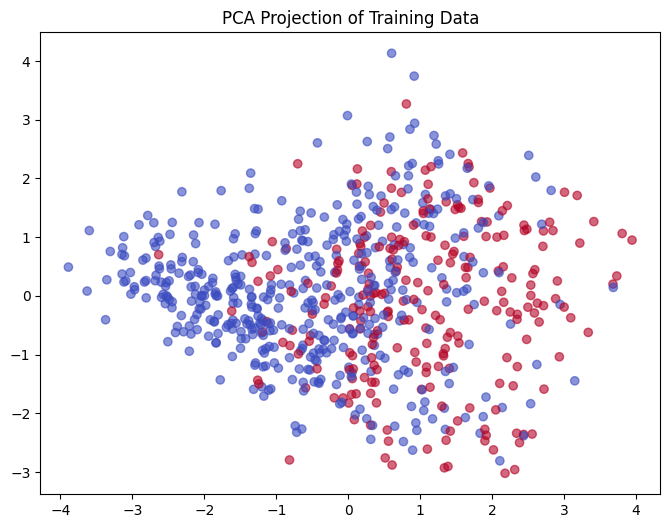

In [1469]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_scaled = StandardScaler().fit_transform(X_train)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='coolwarm', alpha=0.6)
plt.title('PCA Projection of Training Data')
plt.show()


In [1470]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [1471]:
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

In [1472]:
df.iloc[0,:]

Pregnancies                   6.000
Glucose                     148.000
BloodPressure                72.000
SkinThickness                35.000
Insulin                     125.000
BMI                          33.600
DiabetesPedigreeFunction      0.627
Age                          50.000
Outcome                       1.000
Name: 0, dtype: float64

In [1473]:
knn = KNeighborsClassifier(n_neighbors=best_k,metric="euclidean")
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=18)

In [1474]:
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7012987012987013

In [1475]:
knn = KNeighborsClassifier(n_neighbors=best_k,metric="euclidean" )
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=18)

In [1476]:
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7012987012987013

In [1477]:
def apply_feature_weights(X, weights):
    return X * weights

def evaluate_knn(weights):
    X_train_weighted = apply_feature_weights(X_train, weights)
    X_test_weighted = apply_feature_weights(X_test, weights)
    
    model = KNeighborsClassifier(n_neighbors=best_k,metric="euclidean")
    model.fit(X_train_weighted, y_train)
    y_pred = model.predict(X_test_weighted)
    
    return 1 - accuracy_score(y_test, y_pred)  


In [1478]:
initial_weights = np.zeros(X.shape[1]) 

result = minimize(evaluate_knn, initial_weights, method='Powell')
optimal_weights = result.x

print("Optimal weights:", optimal_weights)

Optimal weights: [ 1.59542691  0.55888569  0.22350673 -0.06412396 -0.71190349  2.08720597
 -0.49839757  0.43901271]


In [1479]:
X_train_weighted = apply_feature_weights(X_train, optimal_weights)
X_test_weighted = apply_feature_weights(X_test, optimal_weights)

final_model = KNeighborsClassifier(n_neighbors=best_k,metric="euclidean")
final_model.fit(X_train_weighted, y_train)
final_predictions = final_model.predict(X_test_weighted)

final_accuracy = accuracy_score(y_test, final_predictions)
print("Final Accuracy with optimized weights:", final_accuracy)

Final Accuracy with optimized weights: 0.8311688311688312


In [1480]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.75      0.82      0.78        50
           1       0.59      0.48      0.53        27

    accuracy                           0.70        77
   macro avg       0.67      0.65      0.66        77
weighted avg       0.69      0.70      0.69        77

